In [223]:
# Importing the required libraries
# Checking the Indicators from the WB Library
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import wbdata
pd.set_option("float_format", "{:f}".format)
# wbdata.get_sources()

wbdata.get_indicators(source =2)
# wbdata.get_data('SP.POP.TOTL', country= 'USA')

id                          name
--------------------------  ---------------------------------------------------------------------------------------------------------------------------------------------
AG.CON.FERT.PT.ZS           Fertilizer consumption (% of fertilizer production)
AG.CON.FERT.ZS              Fertilizer consumption (kilograms per hectare of arable land)
AG.LND.AGRI.K2              Agricultural land (sq. km)
AG.LND.AGRI.ZS              Agricultural land (% of land area)
AG.LND.ARBL.HA              Arable land (hectares)
AG.LND.ARBL.HA.PC           Arable land (hectares per person)
AG.LND.ARBL.ZS              Arable land (% of land area)
AG.LND.CREL.HA              Land under cereal production (hectares)
AG.LND.CROP.ZS              Permanent cropland (% of land area)
AG.LND.EL5M.RU.K2           Rural land area where elevation is below 5 meters (sq. km)
AG.LND.EL5M.RU.ZS           Rural land area where elevation is below 5 meters (% of total land area)
AG.LND.EL5M.UR.K2  

In [224]:
# Investigating the result of our request data
data = wbdata.get_countries()
print(type(data))
print(len(data))
print(data[0])   # <-- Look closely at the first item

<class 'wbdata.client.SearchResult'>
296
{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [225]:
# Loop all the values from the wbdata.get_countries() into the country_dict variable
country_variable = []
for k in wbdata.get_countries()[1:]:
    country_variable.append(k)
print(country_variable[1])

{'id': 'AFG', 'iso2Code': 'AF', 'name': 'Afghanistan', 'region': {'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Middle East, North Africa, Afghanistan & Pakistan'}, 'adminregion': {'id': 'MNA', 'iso2code': 'XQ', 'value': 'Middle East, North Africa, Afghanistan & Pakistan (excluding high income)'}, 'incomeLevel': {'id': 'LIC', 'iso2code': 'XM', 'value': 'Low income'}, 'lendingType': {'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}, 'capitalCity': 'Kabul', 'longitude': '69.1761', 'latitude': '34.5228'}


In [226]:
# Now, we need id and name
# We need to save those values into a dictionary
country_names = {}

for country in country_variable:
    code = country["id"]
    name = country["name"]
    country_names[code] = name
print(country_names["AFG"])

# Now, we have a dictionary of Country Code and Country Names

Afghanistan


In [227]:
# Reading the country names and converting Series into the Data Frame
df_country_names_code = pd.Series(country_names)
df_country_names_code = df_country_names_code.to_frame(name ="Country")
df_country_names_code.head(5)

,Country
AFE,Africa Eastern and Southern
AFG,Afghanistan
AFR,Africa
AFW,Africa Western and Central
AGO,Angola


In [228]:
# We have to drop all the names that are related to regions and leave only countries there
clean_countries = df_country_names_code["Country"].to_list()
clean_countries
regions = ['Africa Eastern and Southern', 'Africa Western and Central','Arab World','East Asia & Pacific (IBRD-only countries)',
 'Europe & Central Asia (IBRD-only countries)','IBRD countries classified as high income', 'Latin America & the Caribbean (IBRD-only countries)',
          'Sub-Saharan Africa (IBRD-only countries)', 'Central African Republic','East Asia and the Pacific (IFC classification)',
 'Central Europe and the Baltics','Europe and Central Asia (IFC classification)','Channel Islands','Latin America and the Caribbean (IFC classification)',
 'Middle East and North Africa (IFC classification)','South Asia (IFC classification)', 'East Asia & Pacific (IDA-eligible countries)',
 'Europe & Central Asia (IDA-eligible countries)','Latin America & the Caribbean (IDA-eligible countries)', 'IDA countries in Sub-Saharan Africa not classified as fragile situations ',
 'Dominican Republic','South Asia (IDA-eligible countries)','IDA countries in Sub-Saharan Africa classified as fragile situations ',
           'Sub-Saharan Africa (IDA-eligible countries)','East Asia & Pacific (excluding high income)',
 'Early-demographic dividend','East Asia & Pacific', 'Europe & Central Asia (excluding high income)','Europe & Central Asia','Euro area','European Union','Fragile and conflict affected situations',
'IDA countries classified as fragile situations, excluding Sub-Saharan Africa','Heavily indebted poor countries (HIPC)',
'IBRD, including blend','IBRD only','IDA & IBRD total','IDA total','IDA blend', 'IDA only','Not classified', 'Latin America & Caribbean (excluding high income)','Latin America & Caribbean ',
 'Least developed countries: UN classification','Low income', 'Lower middle income','Low & middle income','Late-demographic dividend', 'Middle East (developing only)', 'Middle East (developing only)',
'Non-resource rich Sub-Saharan Africa countries','IDA countries not classified as fragile situations, excluding Sub-Saharan Africa',
 'OECD members','Other small states','Other small states','Resource rich Sub-Saharan Africa countries',"Sub-Saharan Africa (excluding high income)",
 'East Asia & Pacific (IDA & IBRD countries)','Europe & Central Asia (IDA & IBRD countries)', 'Latin America & the Caribbean (IDA & IBRD countries)',
'Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)', 'Sub-Saharan Africa (IDA & IBRD countries)','Upper middle income',
'Sub-Saharan Africa excluding South Africa and Nigeria',"Middle East, North Africa, Afghanistan & Pakistan",
"Pre-demographic dividend","Middle income","Pre-demographic dividend","Post-demographic dividend","South Asia","South Asia (IDA & IBRD)","World","High income",
"Middle East, North Africa, Afghanistan & Pakistan (excluding high income)",'Middle East, North Africa, Afghanistan & Pakistan (IBRD only)',
"North America","Sub-Saharan Africa","Latin America & Caribbean", 'Sub-Saharan Africa (IFC classification)','Middle East, North Africa, Afghanistan & Pakistan (IDA total)',
'Sub-Saharan Africa excluding South Africa' ,"Africa"]

df_clean_country = df_country_names_code.loc[~df_country_names_code["Country"].isin(regions)]
df_clean_country_indexed = df_clean_country.reset_index().set_index("Country")
df_clean_country_indexed.head(5)

# We get oonly countries after that!
# We can verify it by checking the head() and tail()

,index
Country,
Afghanistan,AFG
Angola,AGO
Albania,ALB
Andorra,AND
United Arab Emirates,ARE


In [229]:
# Get the Data for Population, for 2024, for all countries
# Automatically make them as a DF
df = wbdata.get_dataframe(
    {'SP.POP.TOTL': 'Population'},
    country='all',  # or your list
    date='2024')

df.head()

,Population
country,
Africa Eastern and Southern,769294618.000000
Africa Western and Central,521764076.000000
Arab World,492579811.000000
Caribbean small states,4539060.000000
Central Europe and the Baltics,100050066.000000


In [230]:
# Get the Unmployment Rate for these all countries for 2024
# Unemployment Rate that is Produced by the International Labour Organization (ILO) using their own statistical model
# Because most of the National Estimates were empty for 2024
df_unemployment_rate = wbdata.get_dataframe(
    {
    "SL.UEM.TOTL.ZS" :"Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "SL.TLF.TOTL.IN":"Labor force, total"},
    country='all',  # or your list
    date='2024')
df_unemployment_rate = df_unemployment_rate.reset_index()
df_unemployment_rate = df_unemployment_rate.rename(columns = {"country":"Country"})
df_unemployment_rate.head(5)

,Country,"Unemployment, total (% of total labor force) (modeled ILO estimate)","Labor force, total"
0,Africa Eastern and Southern,7.772654,291834463.000000
1,Africa Western and Central,3.218313,218340363.000000
2,Arab World,9.461238,134086328.000000
3,Caribbean small states,7.423939,1926439.000000
4,Central Europe and the Baltics,3.867636,48956646.000000


In [231]:
# We merge the table by left join, in order to add the population value to our original table with country names
df_merged = df_clean_country_indexed.join(df, how ="left")
df_merged.head()

,index,Population
Country,,
Afghanistan,AFG,42647492.000000
Angola,AGO,37885849.000000
Albania,ALB,2714617.000000
Andorra,AND,81938.000000
United Arab Emirates,ARE,10876981.000000


In [232]:
# Reset the Index and Use "Country" as a column
df_total_clean_dataset = df_merged.reset_index()
df_total_clean_dataset = df_total_clean_dataset.rename(columns ={"level_0":"Country"})
df_total_clean_dataset.head()

,Country,index,Population
0,Afghanistan,AFG,42647492.000000
1,Angola,AGO,37885849.000000
2,Albania,ALB,2714617.000000
3,Andorra,AND,81938.000000
4,United Arab Emirates,ARE,10876981.000000


In [233]:
# The median age value comes from CIA.GOV, we have webscraped the median age value from CIA.GOV
# and exported it to the csv file

median_age = pd.read_csv(r"C:\Users\XCG\Downloads\Country,Median Age (Years).csv")
median_age.head()

,Country,Median Age (Years)
0,Afghanistan,20
1,Albania,36.3
2,Algeria,29.1
3,Andorra,48.8
4,Angola,16.3


In [254]:
# Back to our Population data and its country names


# We had to do the following:

# Break the Population into Categories by using the pd.cut()
# from 1 to 10 million
# from 10 to 50 million
# from 50 to 100 million
# from 100 million to 500 million
# from 500 million and above

labels = ["1 to 10 million","10 to 50 million","50 to 100 million","100 million to 500 million", "Over 1 billion"]

bins = [0,10000000,50000000,100000000,500000000,200000000000]

df_total_clean_dataset["categories"] = pd.cut(df_total_clean_dataset["Population"],bins =bins,labels =labels, right=True)
df_total_clean_dataset.loc[df_total_clean_dataset["categories"]=="1 to 10 million"].sort_values("Population", ascending=False)


,Country,index,Population,categories
91,Israel,ISR,9974400.000000,1 to 10 million
83,Hungary,HUN,9562314.000000,1 to 10 million
190,Togo,TGO,9515236.000000,1 to 10 million
10,Austria,AUT,9178482.000000,1 to 10 million
21,Belarus,BLR,9133712.000000,1 to 10 million
...,...,...,...,...
173,San Marino,SMR,33977.000000,1 to 10 million
116,St. Martin (French part),MAF,26129.000000,1 to 10 million
152,Palau,PLW,17695.000000,1 to 10 million
145,Nauru,NRU,11947.000000,1 to 10 million


In [255]:
df_total_clean_dataset.loc[df_total_clean_dataset["categories"]=="50 to 100 million"].sort_values("Population", ascending=False)

,Country,index,Population,categories
88,"Iran, Islamic Rep.",IRN,91567738.000000,50 to 100 million
198,Turkiye,TUR,85518661.000000,50 to 100 million
48,Germany,DEU,83510950.000000,50 to 100 million
191,Thailand,THA,71668011.000000,50 to 100 million
65,United Kingdom,GBR,69226000.000000,50 to 100 million
200,Tanzania,TZA,68560157.000000,50 to 100 million
61,France,FRA,68516699.000000,50 to 100 million
215,South Africa,ZAF,64007187.000000,50 to 100 million
92,Italy,ITA,58986023.000000,50 to 100 million
97,Kenya,KEN,56432944.000000,50 to 100 million


In [235]:
# We have matched the country names with median age df and retrieved the median age value from the table to our population table
df_total_clean_dataset_incl_median_age = pd.merge(df_total_clean_dataset,median_age, how ="left")
df_total_clean_dataset_incl_median_age.tail(4)

,Country,index,Population,categories,Median Age (Years)
214,"Yemen, Rep.",YEM,40583164.000000,10 to 50 million,NaN
215,South Africa,ZAF,64007187.000000,50 to 100 million,30.4
216,Zambia,ZMB,21314956.000000,10 to 50 million,18.4
217,Zimbabwe,ZWE,16634373.000000,10 to 50 million,21.2


In [236]:
# Retrieve the values of Unemployment rate for the countries

df_total_clean_dataset_incl_median_age_unemprate  = pd.merge(df_total_clean_dataset_incl_median_age,df_unemployment_rate, how ="left")
df_total_clean_dataset_incl_median_age_unemprate.tail(6)

,Country,index,Population,categories,Median Age (Years),"Unemployment, total (% of total labor force) (modeled ILO estimate)","Labor force, total"
212,Samoa,WSM,218019.000000,1 to 10 million,27.4,4.551000,57239.000000
213,Kosovo,XKX,1527324.000000,1 to 10 million,32,NaN,NaN
214,"Yemen, Rep.",YEM,40583164.000000,10 to 50 million,NaN,17.086000,7847788.000000
215,South Africa,ZAF,64007187.000000,50 to 100 million,30.4,33.168000,27765994.000000
216,Zambia,ZMB,21314956.000000,10 to 50 million,18.4,5.961000,7407019.000000
217,Zimbabwe,ZWE,16634373.000000,10 to 50 million,21.2,8.554000,6386440.000000


In [237]:
# Again, we make sure we had to drop all the regions from the country col 
final_df = df_total_clean_dataset_incl_median_age_unemprate.loc[~df_total_clean_dataset_incl_median_age_unemprate["Country"].isin(regions)]
final_df.head(4)

,Country,index,Population,categories,Median Age (Years),"Unemployment, total (% of total labor force) (modeled ILO estimate)","Labor force, total"
0,Afghanistan,AFG,42647492.000000,10 to 50 million,20,13.295000,9132918.000000
1,Angola,AGO,37885849.000000,10 to 50 million,16.3,14.464000,15960547.000000
2,Albania,ALB,2714617.000000,1 to 10 million,36.3,10.250000,1369710.000000
3,Andorra,AND,81938.000000,1 to 10 million,48.8,NaN,NaN


In [238]:
# Let's check top populous countries
pd.set_option('display.precision', 3)
top_10 = final_df.sort_values("Population",ascending = False).head(10)
top_10

,Country,index,Population,categories,Median Age (Years),"Unemployment, total (% of total labor force) (modeled ILO estimate)","Labor force, total"
86,India,IND,1450935791.000000,Over 500 million,29.8,4.202000,607691498.000000
33,China,CHN,1408975000.000000,Over 500 million,40.2,4.571000,773879678.000000
204,United States,USA,340110988.000000,100 million to 500 million,38.9,4.106000,174173594.000000
84,Indonesia,IDN,283487931.000000,100 million to 500 million,31.5,3.300000,143143940.000000
148,Pakistan,PAK,251269164.000000,100 million to 500 million,22.9,5.472000,83643815.000000
140,Nigeria,NGA,232679478.000000,100 million to 500 million,19.3,2.989000,113349564.000000
25,Brazil,BRA,211998573.000000,100 million to 500 million,35.1,7.634000,106790403.000000
16,Bangladesh,BGD,173562364.000000,100 million to 500 million,29.6,4.680000,77355168.000000
164,Russian Federation,RUS,143533851.000000,100 million to 500 million,NaN,2.527000,72516535.000000
58,Ethiopia,ETH,132059767.000000,100 million to 500 million,20.4,3.398000,54470278.000000


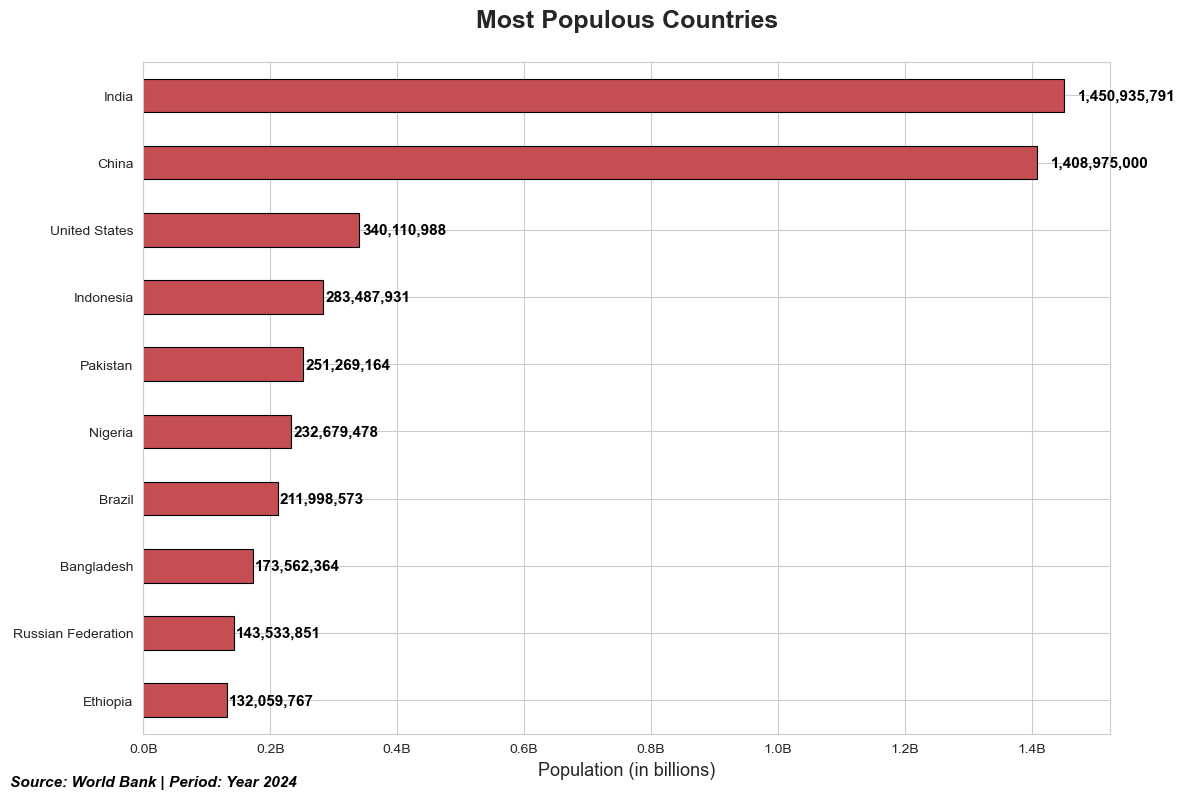

In [239]:
# Let's visualize the populous countries in the Chart

sns.set_style("whitegrid")

top_10 = final_df.sort_values("Population", ascending=False).head(10)

data = top_10.groupby("Country")["Population"].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))

ax = data.plot.barh(color='#c44e52', edgecolor='black', linewidth=0.8)

ax.set_title("Most Populous Countries", 
             fontsize=18, fontweight='bold', pad=25)

ax.set_xlabel("Population (in billions)", fontsize=13)
ax.set_ylabel("")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

for i, (country, pop) in enumerate(data.items()):
    ax.text(pop + pop*0.015, i, f'{int(pop):,}', 
            va='center', fontsize=11, fontweight='bold', color='black')

plt.subplots_adjust(left=0.28)

plt.figtext(0.01, 0.01, "Source: World Bank | Period: Year 2024", 
            fontsize=11, style='italic', color="black",fontweight ="bold", ha="left")

plt.tight_layout()

plt.savefig(r"Top 10 Most Populous Countries.png")
plt.show()

In [240]:
# Correct syntax – one line, works perfectly
final_df.loc[final_df["Country"] == "Russian Federation", "Median Age (Years)"] = 40.3

final_df["Median Age (Years)"] =  pd.to_numeric(final_df["Median Age (Years)"],errors ="coerce")

top_10_median = top_10.groupby("Country")["Median Age (Years)"].sum()
top_10_median

Country
Bangladesh            29.6
Brazil                35.1
China                 40.2
Ethiopia              20.4
India                 29.8
Indonesia             31.5
Nigeria               19.3
Pakistan              22.9
Russian Federation       0
United States         38.9
Name: Median Age (Years), dtype: object

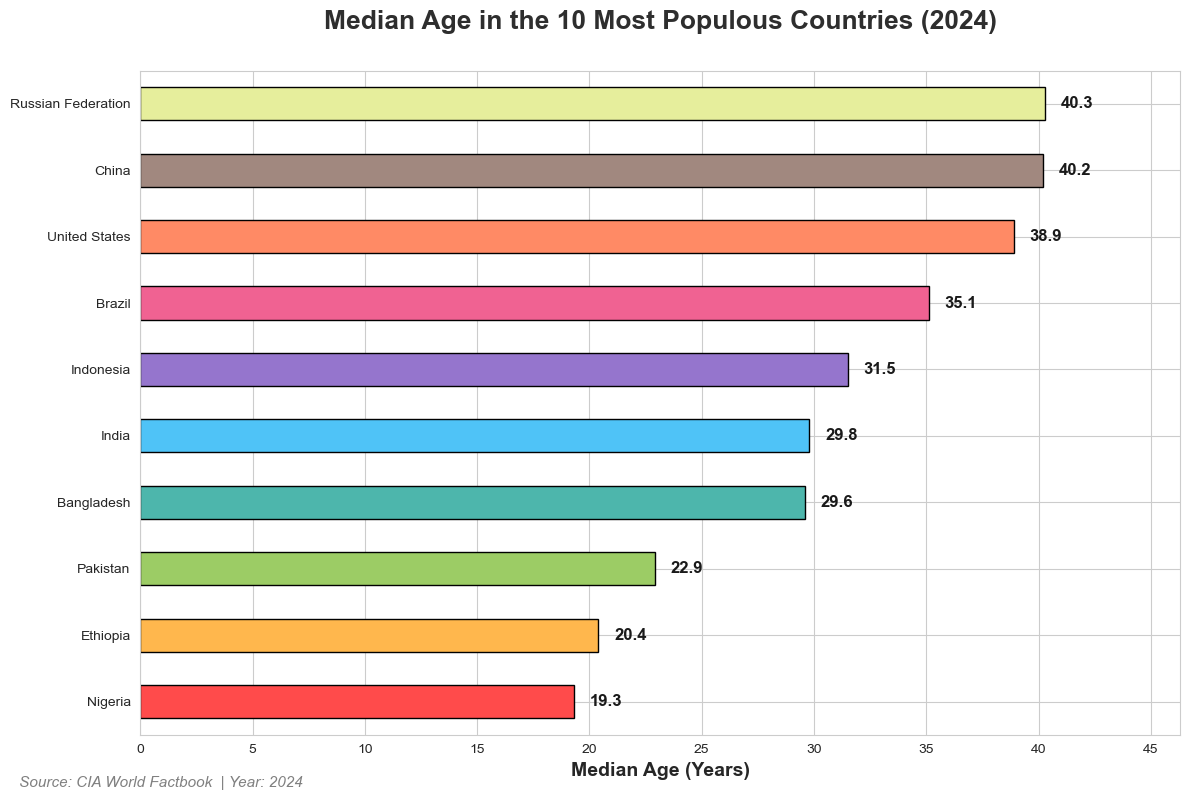

In [260]:
# Let's visualize Median Age of the 10 Most Populous Countries – now super colorful!
sns.set_style("whitegrid")

# Top 10 most populous countries
top_10 = final_df.sort_values("Population", ascending=False).head(10)

# Extract and sort median age (youngest → oldest)
data = top_10.set_index("Country")["Median Age (Years)"].sort_values(ascending=True)

# Create figure
plt.figure(figsize=(12, 8))

# Bright, vibrant, and fully colorful palette
# Options you can swap in: "tab10", "Set2", "husl", "bright", "deep", or this hand-picked one:
colors = ["#FF4B4B", "#FFB74D", "#9CCC65", "#4DB6AC", "#4FC3F7", 
          "#9575CD", "#F06292", "#FF8A65", "#A1887F", "#E6EE9C"]

ax = data.plot.barh(color=colors, edgecolor='black', linewidth=1.0)

# Title & labels
ax.set_title("Median Age in the 10 Most Populous Countries (2024)", 
             fontsize=19, fontweight='bold', pad=30, color="#2E2E2E")
ax.set_xlabel("Median Age (Years)", fontsize=14, fontweight='bold')
ax.set_ylabel("")

# Clean x-axis
ax.set_xlim(0, data.max() + 6)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

# Value labels – bold and easy to read
for i, (country, age) in enumerate(data.items()):
    ax.text(age + 0.7, i, f'{age:.1f}', 
            va='center', fontsize=12, fontweight='bold', color='#1A1A1A')

# Extra space for long country names
plt.subplots_adjust(left=0.35)

# Source – subtle but visible
plt.figtext(0.02, 0.01, "Source: CIA World Factbook  | Year: 2024", 
            fontsize=11, style='italic', color="gray", ha="left")

# Save & show
plt.savefig("Most_Populous_Countries_Median_Age_Colorful.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [244]:
# final_df.head()
top_10_unemployment_rate = top_10.groupby("Country")["Unemployment, total (% of total labor force) (modeled ILO estimate)"].sum()
top_10_unemployment_rate

Country
Bangladesh           4.680000
Brazil               7.634000
China                4.571000
Ethiopia             3.398000
India                4.202000
Indonesia            3.300000
Nigeria              2.989000
Pakistan             5.472000
Russian Federation   2.527000
United States        4.106000
Name: Unemployment, total (% of total labor force) (modeled ILO estimate), dtype: float64

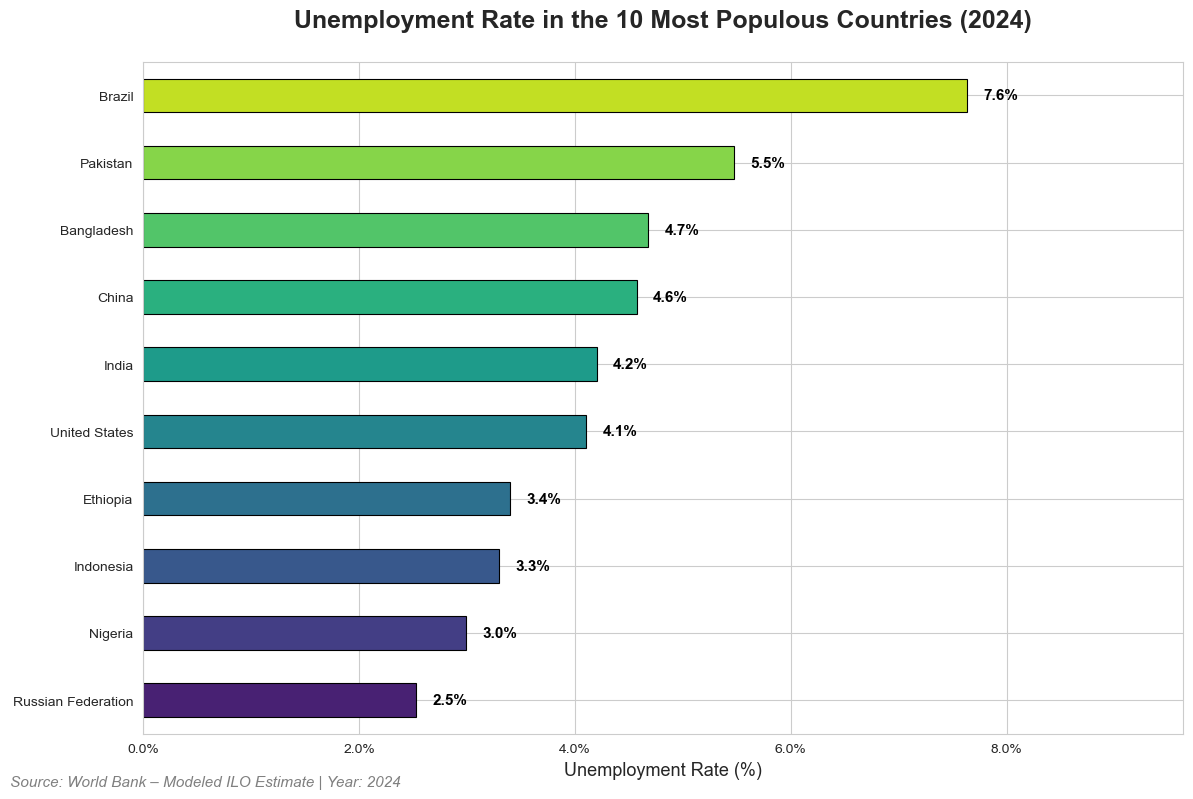

In [250]:
# Let's visualize Unemployment Rate in the 10 Most Populous Countries (2024)
sns.set_style("whitegrid")

# Top 10 most populous countries
top_10 = final_df.sort_values("Population", ascending=False).head(10)

# Extract unemployment rate and sort from lowest to highest (best for horizontal bars)
data = top_10.set_index("Country")[
    "Unemployment, total (% of total labor force) (modeled ILO estimate)"
].sort_values(ascending=True)

# Create figure
plt.figure(figsize=(12, 8))

# Horizontal bar chart with a modern, professional color palette
colors = sns.color_palette("viridis", len(data))  # or try "Blues_d", "rocket", "mako"
ax = data.plot.barh(color=colors, edgecolor='black', linewidth=0.8)

# Title & labels
ax.set_title("Unemployment Rate in the 10 Most Populous Countries (2024)", 
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Unemployment Rate (%)", fontsize=13)
ax.set_ylabel("")

# Fix x-axis: show real percentages (0% to 15%), not billions!
ax.set_xlim(0, data.max() + 2)  # extra space on the right
ax.xaxis.set_major_locator(plt.MultipleLocator(2))  # ticks every 2%
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Add exact values at the end of each bar
for i, (country, rate) in enumerate(data.items()):
    ax.text(rate + 0.15, i, f'{rate:.1f}%', 
            va='center', fontsize=11, fontweight='bold', color='black')

# Make room for long country names (e.g., "United States of America")
plt.subplots_adjust(left=0.32)

# Source — clean and subtle
plt.figtext(0.01, 0.01, "Source: World Bank – Modeled ILO Estimate | Year: 2024", 
            fontsize=11, style='italic', color="gray", ha="left")

# Save high-quality image
plt.savefig("Most_Populous_Countries_Unemployment_Rate_2024.png", 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.tight_layout()
plt.show()

In [147]:
# How about the least populous countries?
# Let's sort the population Values
least_10 = final_df.loc[final_df["categories"] =="1 to 10 million"].sort_values("Population",ascending = True).head(10)
least_10

,Country,index,Population,categories,Median Age (Years),"Unemployment, total (% of total labor force) (modeled ILO estimate)","Labor force, total"
199,Tuvalu,TUV,9646.000000,1 to 10 million,27.8,NaN,NaN
145,Nauru,NRU,11947.000000,1 to 10 million,27.8,NaN,NaN
152,Palau,PLW,17695.000000,1 to 10 million,35.3,NaN,NaN
116,St. Martin (French part),MAF,26129.000000,1 to 10 million,NaN,NaN,NaN
173,San Marino,SMR,33977.000000,1 to 10 million,46.1,NaN,NaN
123,Marshall Islands,MHL,37548.000000,1 to 10 million,25.5,NaN,NaN
118,Monaco,MCO,38631.000000,1 to 10 million,56.9,NaN,NaN
68,Gibraltar,GIB,39329.000000,1 to 10 million,NaN,NaN,NaN
208,British Virgin Islands,VGB,39471.000000,1 to 10 million,NaN,NaN,NaN
109,Liechtenstein,LIE,40197.000000,1 to 10 million,44.2,NaN,NaN


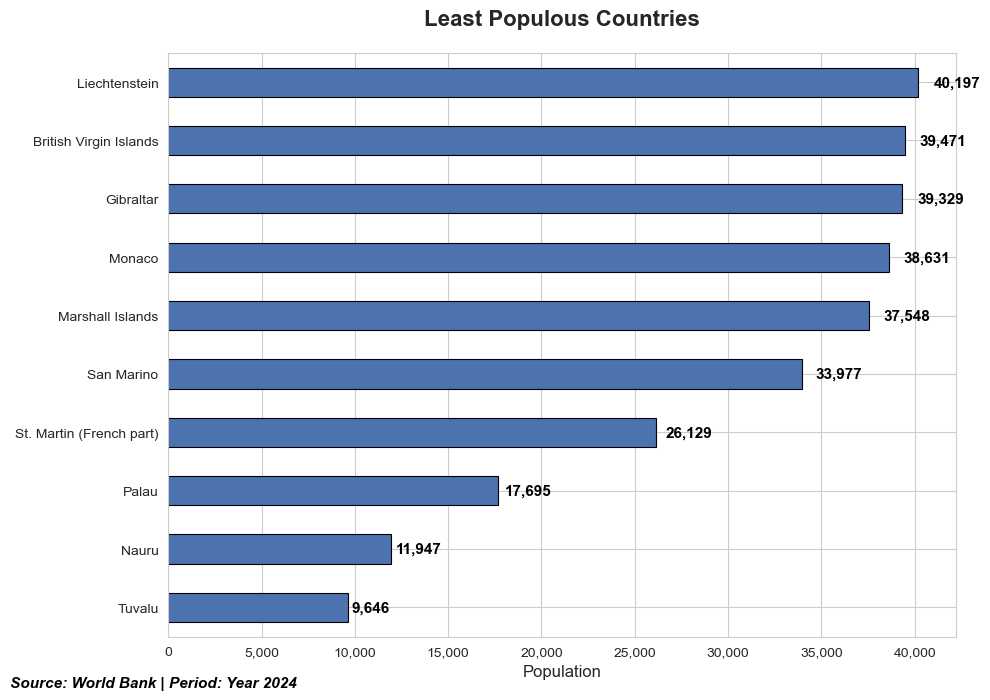

In [153]:
# bottom_10.groupby("Country")["Population"].sum().sort_values().plot.bar(figsize = (10,10))

# Let's visualize the least populous countries in the Chart

sns.set_style("whitegrid")

# Your data: 10 smallest countries
data = bottom_10.groupby("Country")["Population"].sum().sort_values().head(10)

# Create figure
plt.figure(figsize=(10, 7))

# Horizontal bar chart
ax = data.plot.barh(color='#4c72b0', edgecolor='black', linewidth=0.8)

# === TITLE ===
ax.set_title("Least Populous Countries", 
             fontsize=16, fontweight='bold', pad=20)

# === Axis labels ===
ax.set_xlabel("Population", fontsize=12)
ax.set_ylabel("")

# Format x-axis with commas and full numbers (no scientific notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add population numbers next to each bar (cleaner than on top)
for i, (country, pop) in enumerate(data.items()):
    ax.text(pop + pop*0.02, i, f'{int(pop):,}', 
            va='center', fontsize=11, fontweight='bold', color='black')

# Optional: improve country name spacing
plt.subplots_adjust(left=0.28)

# === SOURCE at bottom-left ===
plt.figtext(0.01, 0.01, "Source: World Bank | Period: Year 2024", 
            fontsize=11, style='italic', color="black", ha="left",
           fontweight ="bold")

plt.tight_layout()
plt.savefig(r"Least Populous Countries.png")
plt.show()

In [150]:
# After breaking down the categories, check the number of countries that belong to each of these countries
count_by_categories = final_df.groupby("categories")["categories"].size()
count_by_categories

categories
1 to 10 million               122
10 to 50 million               63
50 to 100 million              15
100 million to 500 million     14
Over 500 million                2
Name: categories, dtype: int64

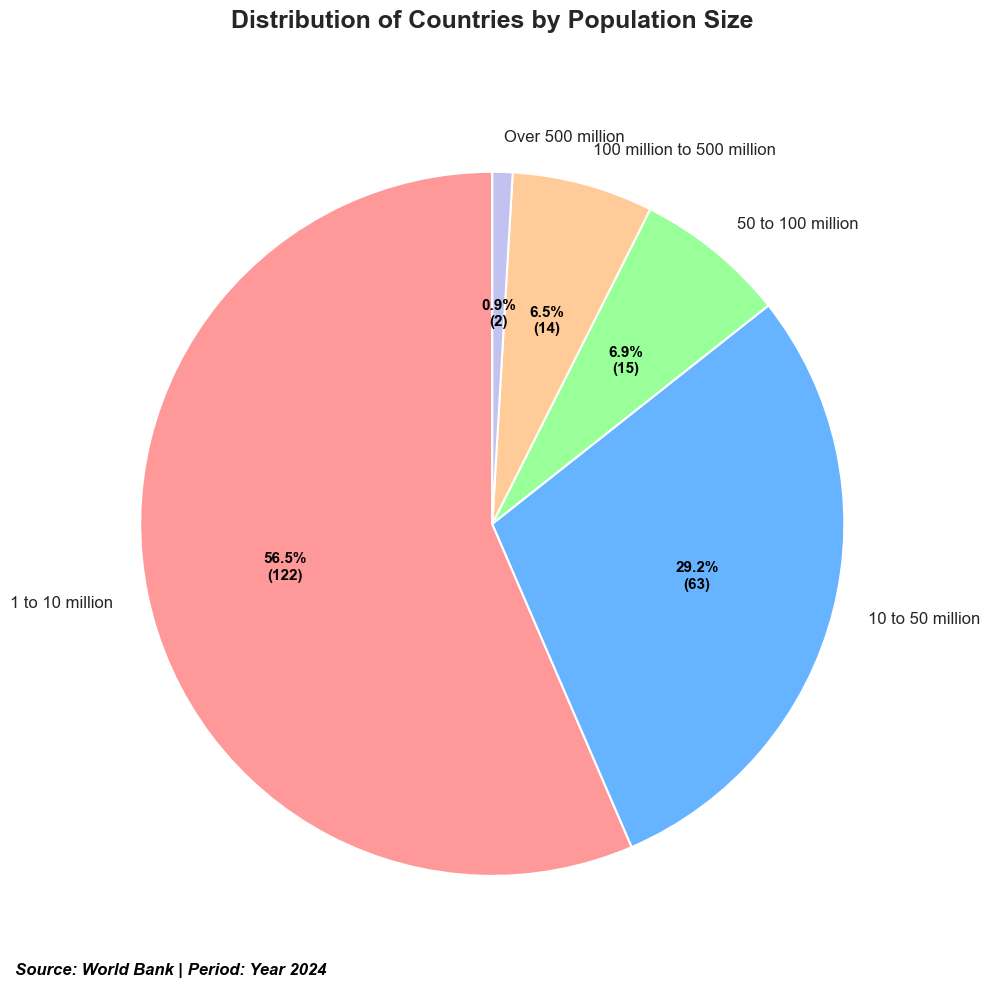

In [154]:
# count_by_categories.plot.pie(figsize =(10,10))
# Visualize it in pie chart

# Colors (looks great in reports)
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

# Create the figure
plt.figure(figsize=(10, 10))

# === PIE CHART ===
wedges, texts, autotexts = plt.pie(count_by_categories,
                                  labels=count_by_categories.index,
                                  autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100*count_by_categories.sum()))})',
                                  startangle=90,
                                  colors=colors,
                                  textprops={'fontsize': 12},
                                  wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})

# Make the percentage text bolder and larger
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

# === TITLE on top ===
plt.title("Distribution of Countries by Population Size", 
          fontsize=18, fontweight="bold", pad=30)

# === SOURCE at bottom-left ===
plt.figtext(0.02, 0.02, "Source: World Bank | Period: Year 2024", 
            fontsize=12, style='italic', color="black", 
            fontweight = "bold",ha="left")

# Equal aspect ratio ensures pie is drawn as a circle
plt.axis('equal')

plt.tight_layout()
plt.savefig(r"Distribution of Countries by Population Size.png")
plt.show()

In [155]:
top_10["index"].to_list()

['IND', 'CHN', 'USA', 'IDN', 'PAK', 'NGA', 'BRA', 'BGD', 'RUS', 'ETH']

In [157]:
# Let's get the population the data for the last 24 years, to determine the average growth rate of those countries

top_countries_pop = wbdata.get_dataframe({'SP.POP.TOTL':"Population"},date=("2000","2024"),
country = top_10["index"].to_list())

top_countries_pop = top_countries_pop.reset_index()

In [161]:
top_countries_pop = top_countries_pop.sort_values(ascending = True, by =["country","date"])
top_countries_pop = top_countries_pop[["date","country","Population"]]
top_countries_pop.head()

,date,country,Population
24,2000,Bangladesh,134544304.000000
23,2001,Bangladesh,136805810.000000
22,2002,Bangladesh,138933658.000000
21,2003,Bangladesh,140970351.000000
20,2004,Bangladesh,142902856.000000


In [168]:
pd.options.display.float_format = "{:,.2f}".format
top_countries_pop["pct_change%"] = top_countries_pop["Population"].pct_change()
top_countries_pop

,date,country,Population,pct_change%
24,2000,Bangladesh,"134,544,304.00",NaN
23,2001,Bangladesh,"136,805,810.00",0.02
22,2002,Bangladesh,"138,933,658.00",0.02
21,2003,Bangladesh,"140,970,351.00",0.01
20,2004,Bangladesh,"142,902,856.00",0.01
...,...,...,...,...
229,2020,United States,"331,577,720.00",0.00
228,2021,United States,"332,099,760.00",0.00
227,2022,United States,"334,017,321.00",0.01
226,2023,United States,"336,806,231.00",0.01


In [169]:
top_countries_pop.info()

<class 'wbdata.client.DataFrame'>
Int64Index: 250 entries, 24 to 225
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         250 non-null    object 
 1   country      250 non-null    object 
 2   Population   250 non-null    float64
 3   pct_change%  249 non-null    float64
dtypes: float64(2), object(2)
memory usage: 9.8+ KB


In [170]:
# In order to avoid the last value of the country to overlap, with the next one, I will keep the the first year of each country as empty
# Which will make sense, because we don't have a value for 1999
top_countries_pop.loc[top_countries_pop["date"] == "2000",["pct_change%"]] = "nan"

In [178]:
# Then apply percentage change age to the previous ones we have done
top_countries_pop["pct_change%"] = pd.to_numeric(top_countries_pop["pct_change%"],errors="coerce")


In [182]:
# Calculate the Average Growth for the last 24 years

pd.options.display.float_format = "{:,.4f}".format

top_countries_pop.groupby("country")["pct_change%"].median().sort_values(ascending=False)


country
Ethiopia              0.0280
Nigeria               0.0275
Pakistan              0.0191
India                 0.0136
Indonesia             0.0126
Bangladesh            0.0095
United States         0.0082
Brazil                0.0081
China                 0.0055
Russian Federation   -0.0009
Name: pct_change%, dtype: float64

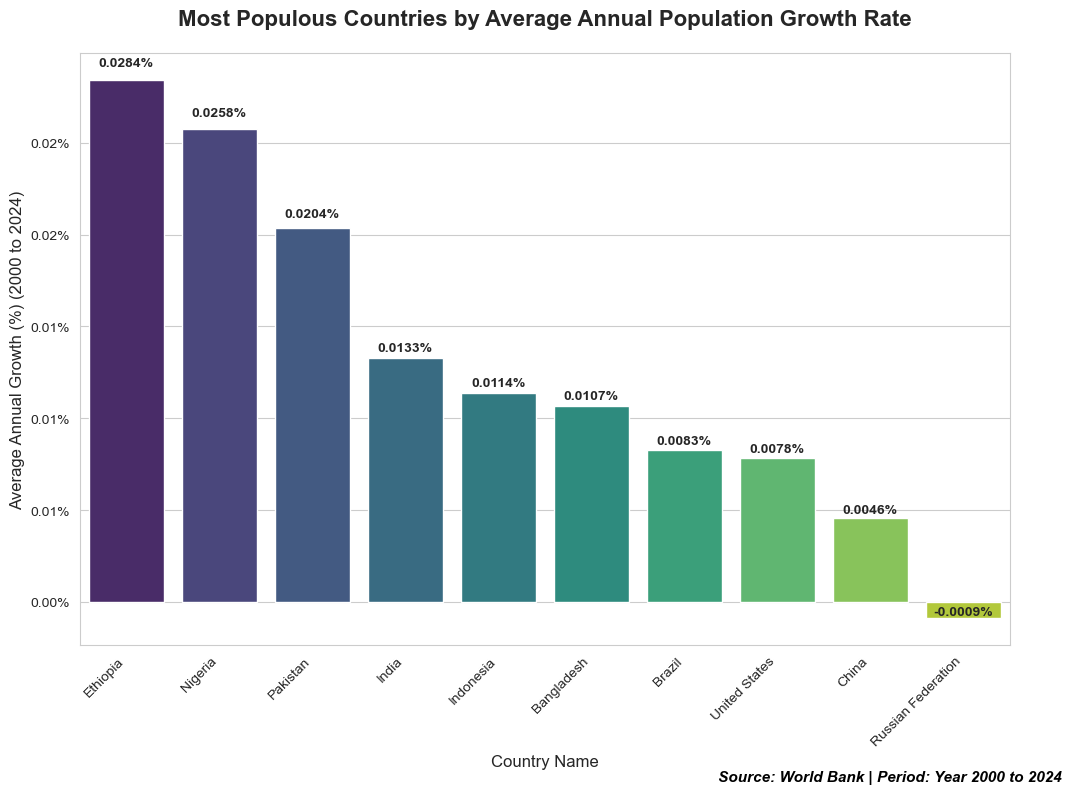

<Figure size 640x480 with 0 Axes>

In [257]:
# top_countries_pop.groupby("country")["pct_change%"].mean().sort_values(ascending=False).plot.bar(figsize=(10,10))

# Let's visualize the average growth for the last 24 years
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Your data
data = top_countries_pop.groupby("country")["pct_change%"].mean().sort_values(ascending=False).head(15)

# Barplot
ax = sns.barplot(x=data.index, y=data.values, palette="viridis")

# ─────── TITLE (add here) ───────
ax.set_title("Most Populous Countries by Average Annual Population Growth Rate", 
             fontsize=16, fontweight="bold", pad=20)

# ─────── Axis labels ───────
ax.set_xlabel("Country Name", fontsize=12)
ax.set_ylabel("Average Annual Growth (%) (2000 to 2024)", fontsize=12)

# Show full percentage values on Y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}%'))

# Values on top of each bar
for i, v in enumerate(data.values):
    ax.text(i, v + v*0.02, f'{v:.4f}%', ha='center', va='bottom', fontweight='bold')

# Rotate long country names
plt.xticks(rotation=45, ha='right')

# ─────── SOURCE (add here – at the very bottom) ───────
plt.figtext(0.8, 0.01, "Source: World Bank | Period: Year 2000 to 2024", 
            ha="center", fontsize=11, style='italic', color="black",
           fontweight = "bold")

# Make room for title + rotated labels + source
plt.subplots_adjust(top=0.92, bottom=0.18)

plt.show()
plt.savefig(r" Average Annual Population Growth Rate.jpg")